In [1]:
import torch
import sys
print("Interpreter:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Interpreter: d:\maga25\VKRTimeSeries\.venv\Scripts\python.exe
CUDA available: True
GPU name: NVIDIA GeForce GTX 1660


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if device.type == 'cuda':
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")
    print(f"Всего видеопамяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Используемое устройство: cuda
Видеокарта: NVIDIA GeForce GTX 1660
Всего видеопамяти: 6.44 GB


In [3]:
# Standard
import random

import numpy as np
import pandas as pd
import torch

# Third Party
from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)

# First Party
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index

d:\maga25\VKRTimeSeries\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [5]:
import os
import numpy as np
import pandas as pd
import torch
from transformers import PatchTSTConfig, PatchTSTForPrediction
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.util import select_by_index
from sklearn.metrics import mean_squared_error

# ============================================================
# 1. Параметры ETTh1 (должны совпадать с обучением)
# ============================================================
dataset = "data/ETTh1.csv"                  # путь к файлу ETTh1.csv
context_length = 512
forecast_horizon = 96
patch_length = 12
timestamp_column = "date"
id_columns = []
forecast_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]

# ============================================================
# 2. Загрузка и разбиение данных ETTh1 (как при обучении)
# ============================================================
data = pd.read_csv(dataset, parse_dates=[timestamp_column])

train_end_index = 12 * 30 * 24
valid_start_index = train_end_index - context_length
valid_end_index = train_end_index + 4 * 30 * 24
test_start_index = train_end_index + 4 * 30 * 24 - context_length
test_end_index = train_end_index + 8 * 30 * 24

train_data = select_by_index(data, id_columns, start_index=None, end_index=train_end_index)
# valid_data не нужен для теста, но можно создать для полноты
test_data = select_by_index(data, id_columns, start_index=test_start_index, end_index=test_end_index)

print(f"Train: {len(train_data)} строк, Test: {len(test_data)} строк")

# ============================================================
# 3. Препроцессор ETTh1 (обучаем на train)
# ============================================================
tsp_etth1 = TimeSeriesPreprocessor(
    timestamp_column=timestamp_column,
    id_columns=id_columns,
    target_columns=forecast_columns,
    scaling=True,
)
tsp_etth1.train(train_data)

# Тестовый датасет (окна)
test_dataset_etth1 = ForecastDFDataset(
    tsp_etth1.preprocess(test_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
    stride=1
)
print(f"Тестовых окон: {len(test_dataset_etth1)}")

# ============================================================
# 4. Загрузка дообученной модели (Weather) и адаптация к 7 каналам
# ============================================================
weather_model_path = "./patchtst_etth1_weather_hourly"   # путь к вашей модели

# Загружаем конфигурацию дообученной модели
old_config = PatchTSTConfig.from_pretrained(weather_model_path)

# Создаём новую конфигурацию для 7 каналов ETTh1
new_config_etth1 = PatchTSTConfig(
    num_input_channels=len(forecast_columns),   # 7
    context_length=context_length,
    patch_length=patch_length,
    prediction_length=forecast_horizon,
    patch_stride=old_config.patch_length, 
    d_model=old_config.d_model,
    num_attention_heads=old_config.num_attention_heads,
    num_hidden_layers=old_config.num_hidden_layers,
    ffn_dim=old_config.ffn_dim,
    dropout=old_config.dropout,
    head_dropout=old_config.head_dropout,
    pooling_type=old_config.pooling_type,
    channel_attention=old_config.channel_attention,
    scaling=old_config.scaling,
    loss=old_config.loss,
    pre_norm=old_config.pre_norm,
    norm_type=old_config.norm_type,
    do_mask_input=False   # при тестировании маскировка не нужна
)

# Загружаем модель, игнорируя несовместимости размеров (входной слой)
model_adapted = PatchTSTForPrediction.from_pretrained(
    weather_model_path,
    config=new_config_etth1,
    ignore_mismatched_sizes=True,
    device_map='cpu'        # можно оставить 'cuda' если есть GPU
)
model_adapted.eval()
print("✅ Модель загружена и адаптирована для 7 каналов ETTh1")

# ============================================================
# 5. Прямой forward на всех тестовых примерах
# ============================================================
all_preds = []
all_labels = []

with torch.no_grad():
    for i in range(len(test_dataset_etth1)):
        sample = test_dataset_etth1[i]
        past = sample['past_values'].unsqueeze(0)  # (1, context_length, 7)
        output = model_adapted(past_values=past)
        if hasattr(output, 'prediction_outputs'):
            pred = output.prediction_outputs.squeeze(0).cpu().numpy()
        elif hasattr(output, 'logits'):
            pred = output.logits.squeeze(0).cpu().numpy()
        else:
            raise ValueError("Нет prediction_outputs или logits")
        all_preds.append(pred)
        all_labels.append(sample['future_values'].numpy())

all_preds = np.array(all_preds)   # (num_samples, 96, 7)
all_labels = np.array(all_labels)
print(f"all_preds.shape: {all_preds.shape}")
print(f"all_labels.shape: {all_labels.shape}")

# ============================================================
# 6. MSE в нормированном пространстве
# ============================================================
mse_norm = np.mean((all_preds - all_labels) ** 2)
print(f"Test loss на ETTh1 (MSE в нормированном пространстве): {mse_norm:.4f}")

# ============================================================
# 7. RMSE для OT в исходных единицах
# ============================================================
ot_idx = forecast_columns.index('OT')

# Берём общий скалер (он один, ключ '0')
scaler = list(tsp_etth1.target_scaler_dict.values())[0]

# Преобразуем все предсказания и истинные значения к плоскому виду (все временные шаги)
all_true_flat = all_labels.reshape(-1, len(forecast_columns))   # (total_time_steps, 7)
all_pred_flat = all_preds.reshape(-1, len(forecast_columns))

# Инвертируем масштабирование для всех признаков
true_inv = scaler.inverse_transform(all_true_flat)
pred_inv = scaler.inverse_transform(all_pred_flat)

# Извлекаем столбец OT
true_ot_inv = true_inv[:, ot_idx].reshape(-1, 1)
pred_ot_inv = pred_inv[:, ot_idx].reshape(-1, 1)

rmse_ot = np.sqrt(mean_squared_error(true_ot_inv, pred_ot_inv))
print(f"RMSE для OT (в исходных единицах, градусы): {rmse_ot:.4f}")

print("✅ Оценка завершена.")

Train: 8640 строк, Test: 3392 строк
Тестовых окон: 2785


Loading weights: 100%|██████████| 71/71 [00:00<00:00, 35797.04it/s]
[transformers] PatchTSTForPrediction LOAD REPORT from: ./patchtst_etth1_weather_hourly
Key                                           | Status   |                                                                                           
----------------------------------------------+----------+-------------------------------------------------------------------------------------------
head.projection.weight                        | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([96, 1792]) vs model:torch.Size([96, 5376])
model.encoder.positional_encoder.position_enc | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([14, 128]) vs model:torch.Size([42, 128])  

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Модель загружена и адаптирована для 7 каналов ETTh1
all_preds.shape: (2785, 96, 7)
all_labels.shape: (2785, 96, 7)
Test loss на ETTh1 (MSE в нормированном пространстве): 0.8418
RMSE для OT (в исходных единицах, градусы): 3.0641
✅ Оценка завершена.


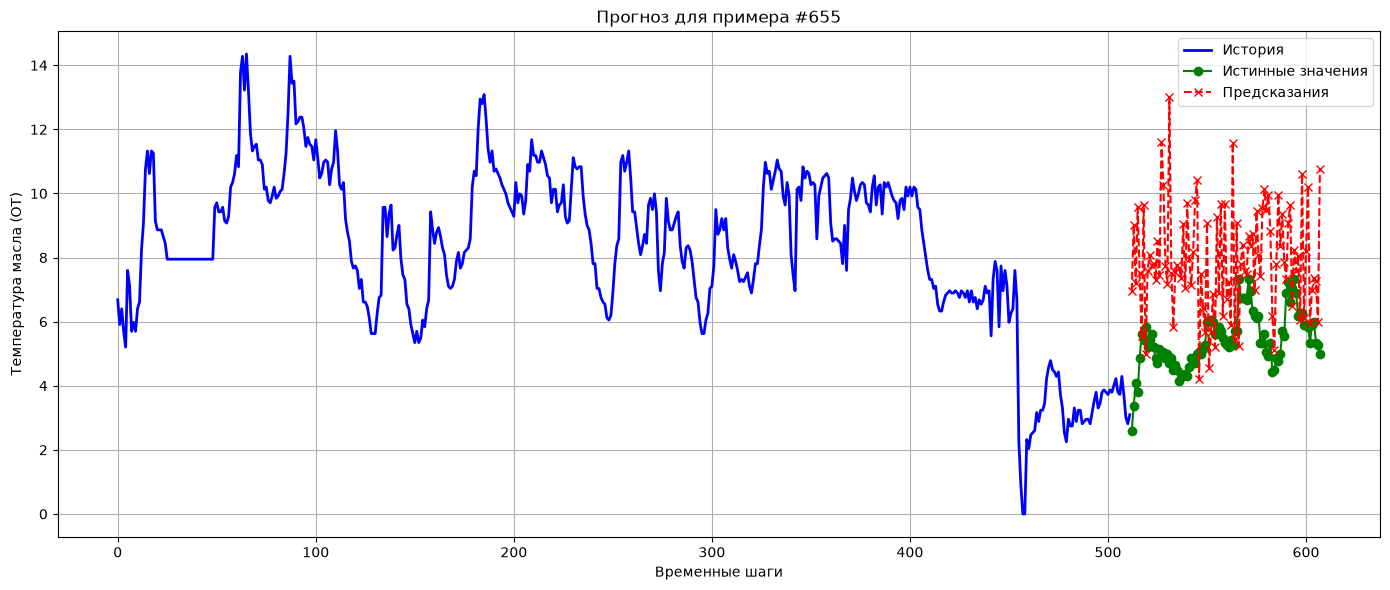

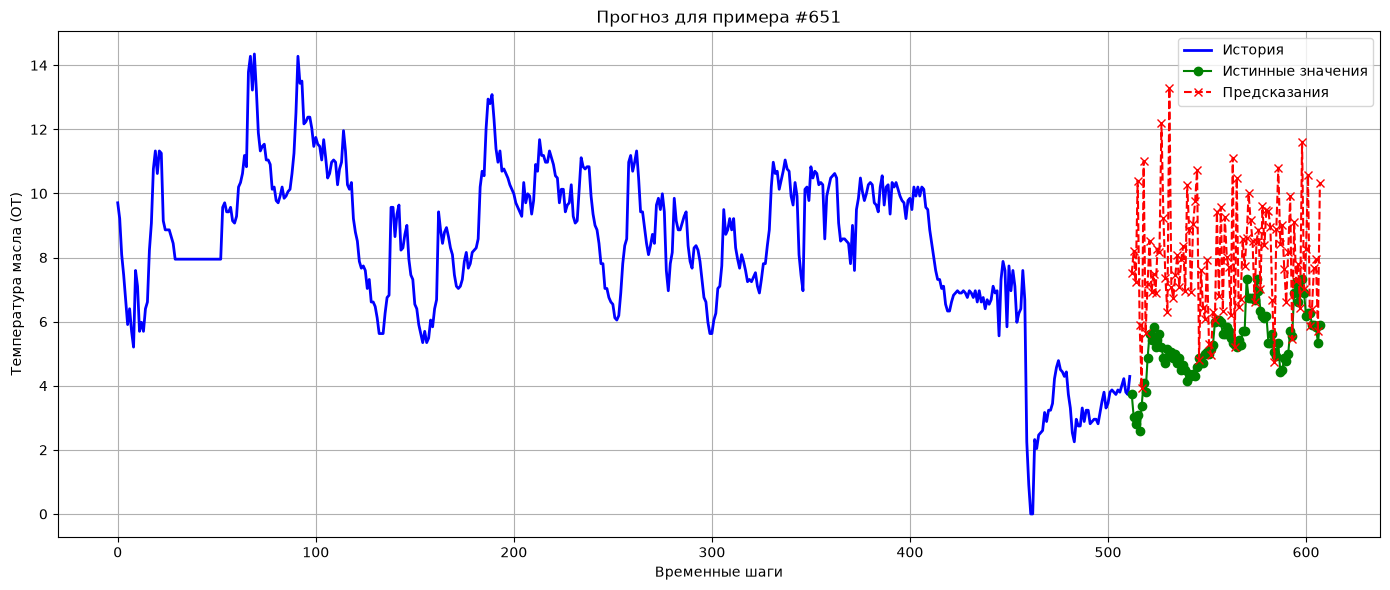

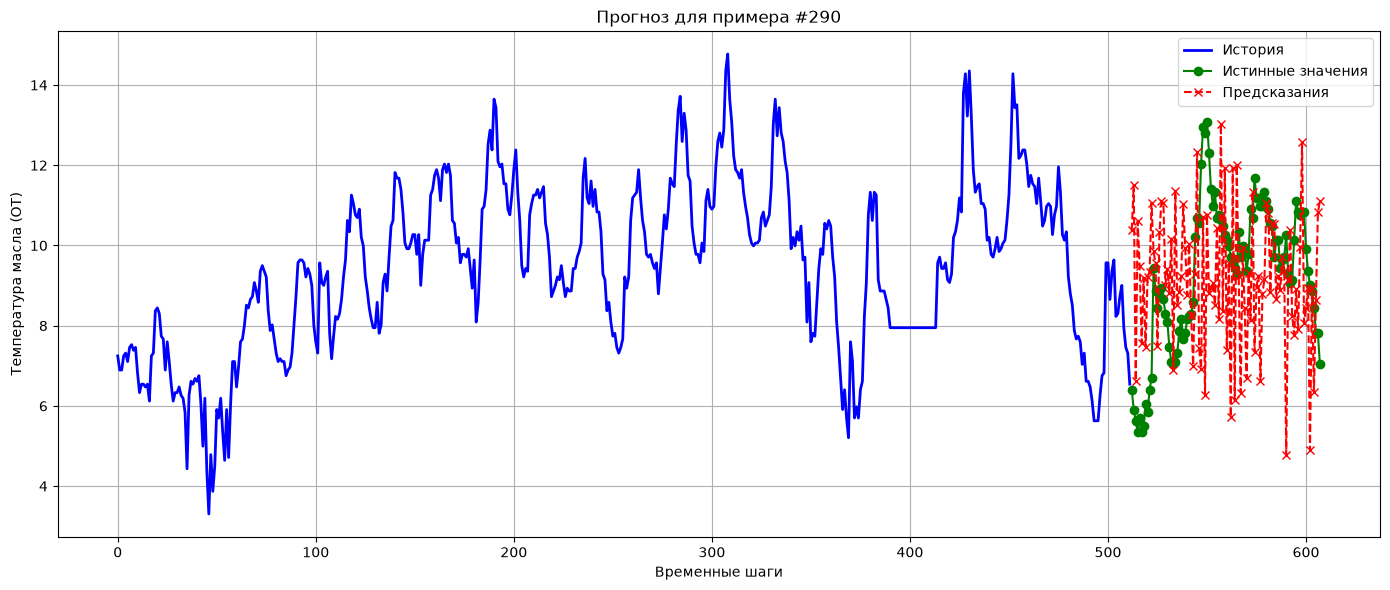

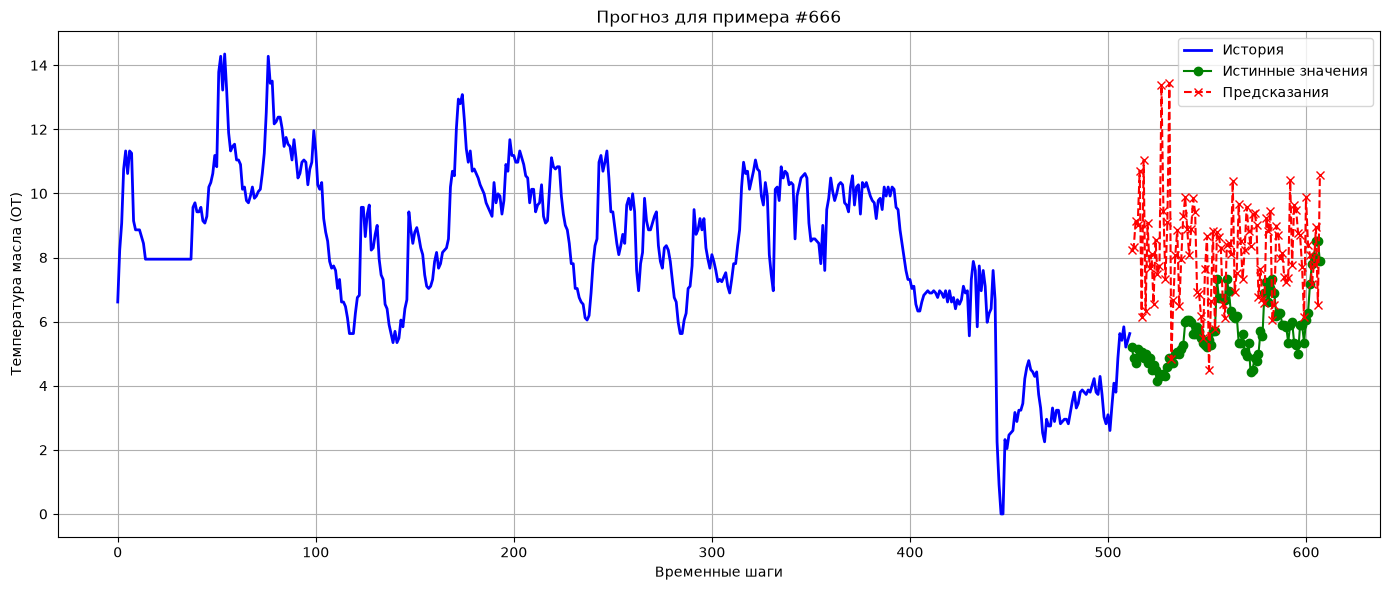

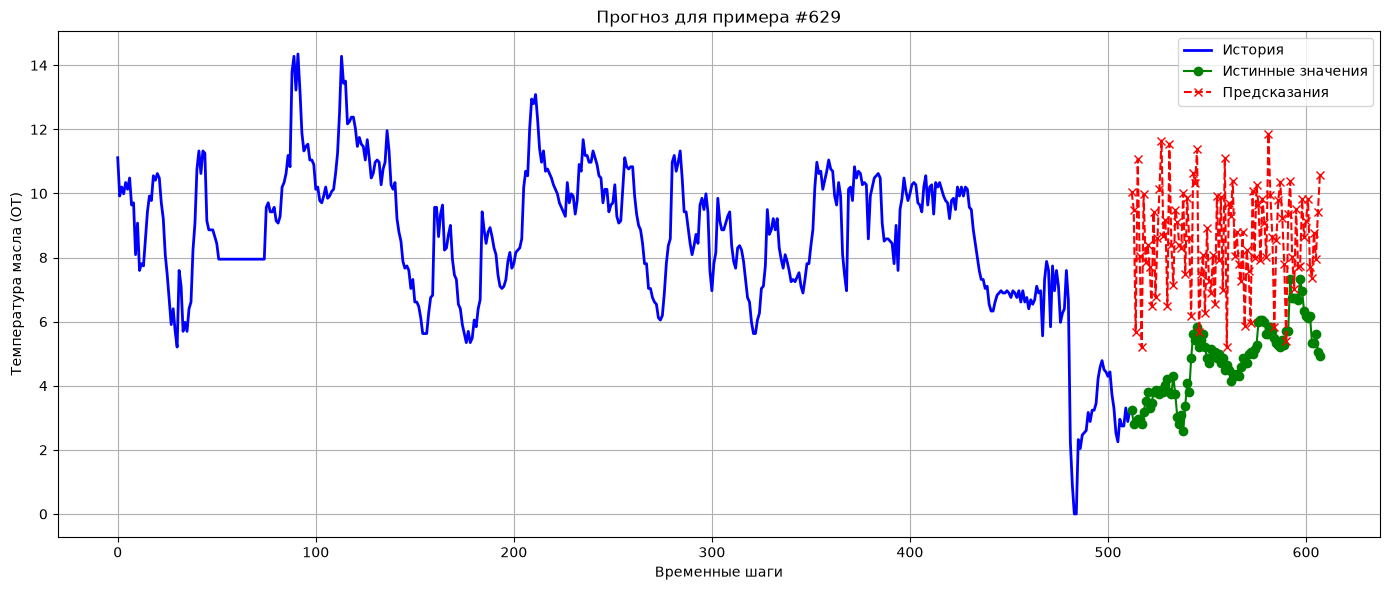

In [ ]:
# ============================================================
# 8. Визуализация прогнозов для нескольких окон
# ============================================================
import matplotlib.pyplot as plt

col_name = "OT"
col_idx = forecast_columns.index(col_name)
scaler = list(tsp_etth1.target_scaler_dict.values())[0]  # общий скалер

# Выберите индексы окон, которые хотите отобразить (можно изменить)
indices = [655, 651, 290, 666, 629]  # пример

for num, idx in enumerate(indices):
    sample = test_dataset_etth1[idx]
    # Контекст (история)
    context = sample['past_values'].numpy().reshape(-1, len(forecast_columns))
    # Истинные будущие значения
    true_future = sample['future_values'].numpy().reshape(-1, len(forecast_columns))
    # Предсказания
    pred_future = all_preds[idx].reshape(-1, len(forecast_columns))
    
    # Обратное масштабирование
    context_inv = scaler.inverse_transform(context)
    true_inv = scaler.inverse_transform(true_future)
    pred_inv = scaler.inverse_transform(pred_future)
    
    plt.figure(figsize=(14, 6))
    x_context = np.arange(context_length)
    x_future = np.arange(context_length, context_length + forecast_horizon)
    
    plt.plot(x_context, context_inv[:, col_idx], label='История', color='blue', linewidth=2)
    plt.plot(x_future, true_inv[:, col_idx], label='Истинные значения', color='green', marker='o', linestyle='-', linewidth=1.5)
    plt.plot(x_future, pred_inv[:, col_idx], label='Предсказания', color='red', marker='x', linestyle='--', linewidth=1.5)
    
    plt.xlabel('Временные шаги')
    plt.ylabel('Температура масла (OT)')
    plt.title(f'Прогноз для примера №{num}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()